In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("heart.csv")

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trtbps    303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalachh  303 non-null    int64  
 8   exng      303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slp       303 non-null    int64  
 11  caa       303 non-null    int64  
 12  thall     303 non-null    int64  
 13  output    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [7]:
df[df.duplicated()]

,age,sex,cp,trtbps,chol,fbs,restecg,thalachh,exng,oldpeak,slp,caa,thall,output
164,38,1,2,138,175,0,1,173,0,0.0,2,4,2,1


In [9]:
df.drop_duplicates(keep = 'first', inplace = True)

Gender Categorization

Number of people having sex as 1 are 206 and the number of people having sex as 0 are 96


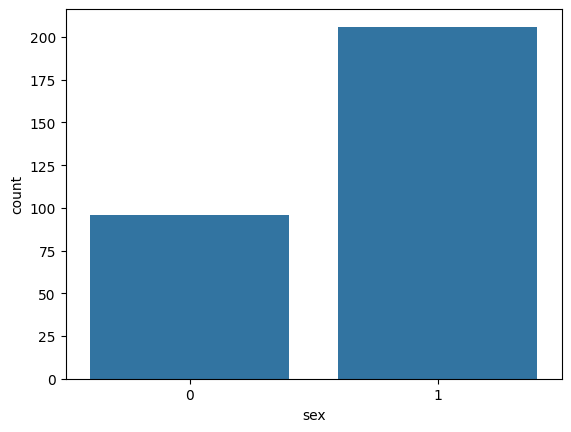

In [14]:
x = df.sex.value_counts()
print(f'Number of people having sex as 1 are {x[1]} and the number of people having sex as 0 are {x[0]}')
sns.countplot(data = df, x = 'sex')
plt.show()

Number of people having sex as 1 are 206 and the number of people having sex as 0 are 96


cp
0    143
2     86
1     50
3     23
Name: count, dtype: int64


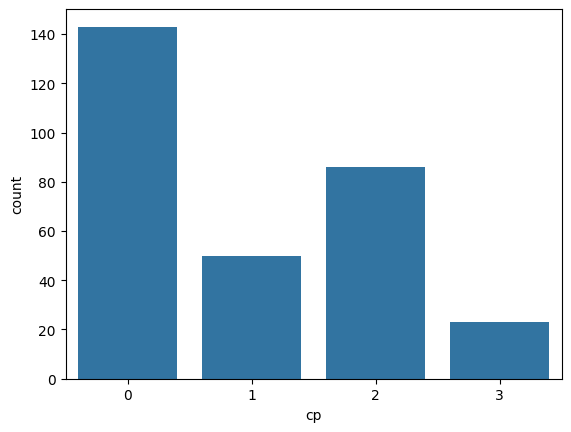

In [15]:
x = df.cp.value_counts()
print(x)
sns.countplot(data = df, x = 'cp')
plt.show()

<Figure size 1000x1000 with 0 Axes>

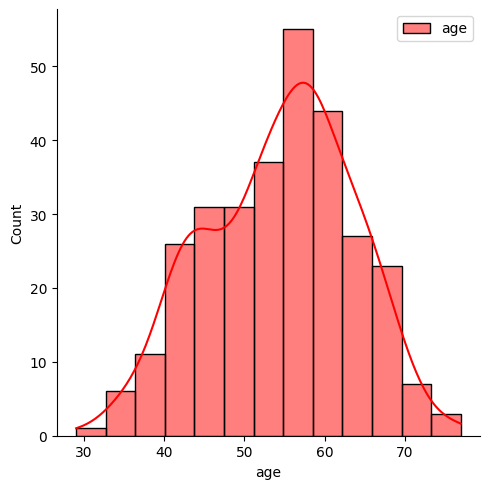

In [16]:
plt.figure(figsize = (10, 10))
sns.displot(df.age, color = 'red', label = 'age', kde = True)
plt.legend()

<Figure size 1000x1000 with 0 Axes>

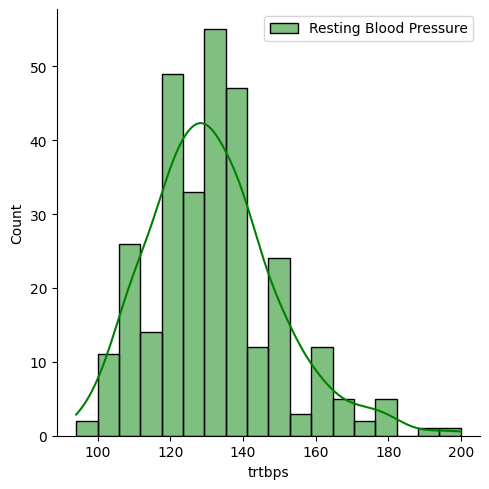

In [18]:
plt.figure(figsize = (10, 10))
sns.displot(df.trtbps, color = 'green', label = 'Resting Blood Pressure', kde = True)
plt.legend()

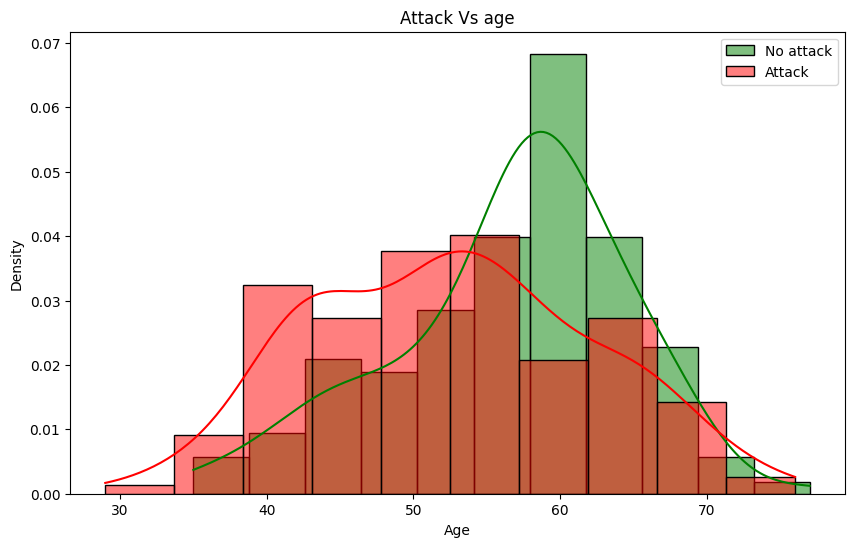

In [24]:
plt.figure(figsize = (10,6))
sns.histplot(df[df['output']==0]['age'], color = 'green', kde = True, stat = 'density', alpha = 0.5, label = 'No attack')
sns.histplot(df[df['output']==1]['age'], color = 'red', kde = True, stat = 'density', alpha = 0.5, label = "Attack")
plt.title('Attack Vs age')
plt.xlabel('Age')
plt.ylabel('Density')
plt.legend()
plt.show()

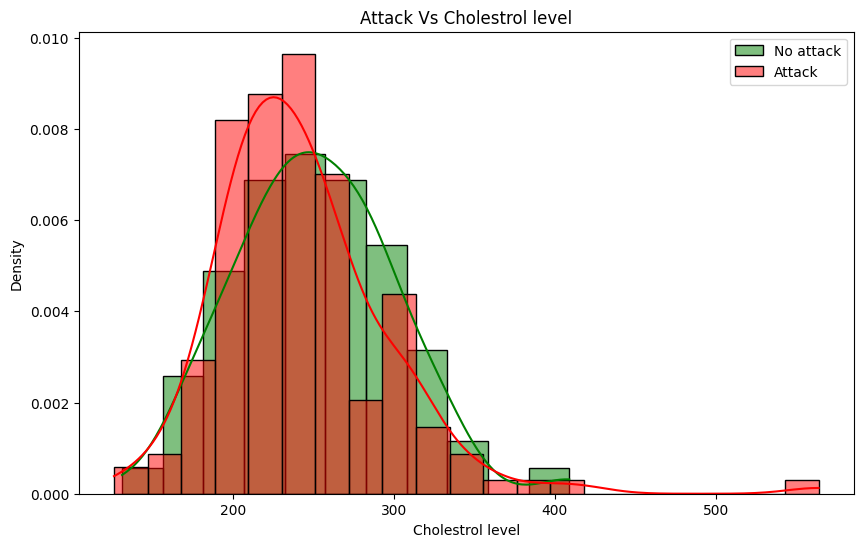

In [25]:
plt.figure(figsize = (10,6))
sns.histplot(df[df['output']==0]['chol'], color = 'green', kde = True, stat = 'density', alpha = 0.5, label = 'No attack')
sns.histplot(df[df['output']==1]['chol'], color = 'red', kde = True, stat = 'density', alpha = 0.5, label = "Attack")
plt.title('Attack Vs Cholestrol level')
plt.xlabel('Cholestrol level')
plt.ylabel('Density')
plt.legend()
plt.show()

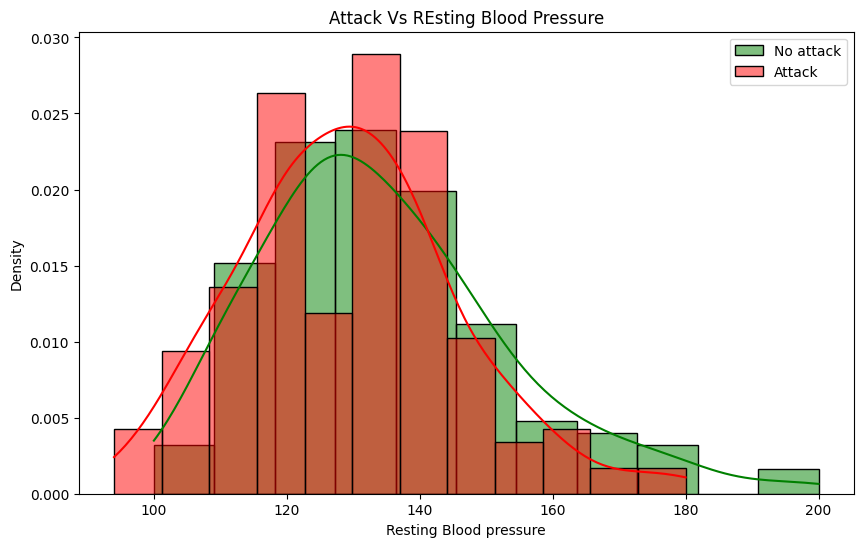

In [26]:
plt.figure(figsize = (10,6))
sns.histplot(df[df['output']==0]['trtbps'], color = 'green', kde = True, stat = 'density', alpha = 0.5, label = 'No attack')
sns.histplot(df[df['output']==1]['trtbps'], color = 'red', kde = True, stat = 'density', alpha = 0.5, label = "Attack")
plt.title('Attack Vs REsting Blood Pressure')
plt.xlabel('Resting Blood pressure')
plt.ylabel('Density')
plt.legend()
plt.show()

In [28]:
y = df.iloc[:,-1].values
x = df.iloc[:,1:-1].values

In [30]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(x, y, random_state = 42, test_size = 0.25)

In [31]:
from sklearn.preprocessing import StandardScaler
sc= StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.fit_transform(X_test)

In [32]:
from sklearn.naive_bayes import GaussianNB
gnb = GaussianNB()
gnb.fit(X_train, y_train)

GaussianNB()

In [33]:
y_pred = gnb.predict(X_test)
from sklearn.metrics import accuracy_score
accuracy_score(y_pred, y_test)

0.8947368421052632